In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/processed/energy_agent_dataset.csv"
)

df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

df.head()

,building_id,timestamp,meter_reading,site_id,primary_use,square_feet,air_temperature,dew_temperature,wind_speed,hour,day_of_week,month
0,51,2016-01-01 00:00:00,0.0,0,Parking,387638,25.0,20.0,0.0,0,4,1
1,51,2016-01-01 01:00:00,0.0,0,Parking,387638,24.4,21.1,1.5,1,4,1
2,51,2016-01-01 02:00:00,0.0,0,Parking,387638,22.8,21.1,0.0,2,4,1
3,51,2016-01-01 03:00:00,0.0,0,Parking,387638,21.1,20.6,0.0,3,4,1
4,51,2016-01-01 04:00:00,0.0,0,Parking,387638,20.0,20.0,2.6,4,4,1


In [3]:
print("Dataset Shape:")

print(df.shape)

print("\nDataset Information:")

df.info()

Dataset Shape:
(50880, 12)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 50880 entries, 0 to 50879
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   building_id      50880 non-null  int64         
 1   timestamp        50880 non-null  datetime64[us]
 2   meter_reading    50880 non-null  float64       
 3   site_id          50880 non-null  int64         
 4   primary_use      50880 non-null  str           
 5   square_feet      50880 non-null  int64         
 6   air_temperature  50880 non-null  float64       
 7   dew_temperature  50880 non-null  float64       
 8   wind_speed       50880 non-null  float64       
 9   hour             50880 non-null  int64         
 10  day_of_week      50880 non-null  int64         
 11  month            50880 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(6), str(1)
memory usage: 5.3 MB


In [4]:
missing_values = (
    df.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing_values

building_id        0
timestamp          0
meter_reading      0
site_id            0
primary_use        0
square_feet        0
air_temperature    0
dew_temperature    0
wind_speed         0
hour               0
day_of_week        0
month              0
dtype: int64

In [5]:
df.describe()

,building_id,timestamp,meter_reading,site_id,square_feet,air_temperature,dew_temperature,wind_speed,hour,day_of_week,month
count,50880.000000,50880,50880.000000,50880.000000,50880.000000,50880.000000,50880.000000,50880.000000,50880.000000,50880.000000,50880.000000
mean,632.126631,2016-02-14 22:34:21.084905,409.731258,5.899607,132630.531506,9.791763,1.668980,3.734253,11.500354,2.995047,1.984100
min,51.000000,2016-01-01 00:00:00,0.000000,0.000000,4000.000000,-28.800000,-35.000000,0.000000,0.000000,0.000000,1.000000
25%,203.000000,2016-01-23 07:00:00,10.000000,2.000000,15120.000000,3.300000,-4.400000,2.100000,6.000000,1.000000,1.000000
50%,634.000000,2016-02-14 13:00:00,49.000000,4.000000,63348.000000,10.000000,1.100000,3.100000,11.500000,3.000000,2.000000
75%,927.000000,2016-03-08 14:00:00,278.467500,9.000000,182986.000000,16.700000,8.300000,5.100000,18.000000,5.000000,3.000000
max,1389.000000,2016-03-31 23:00:00,12571.000000,15.000000,745671.000000,32.800000,22.800000,19.000000,23.000000,6.000000,3.000000
std,396.478727,NaN,1057.603303,4.667340,176331.613561,9.638639,9.275074,2.496310,6.921999,1.999512,0.825079


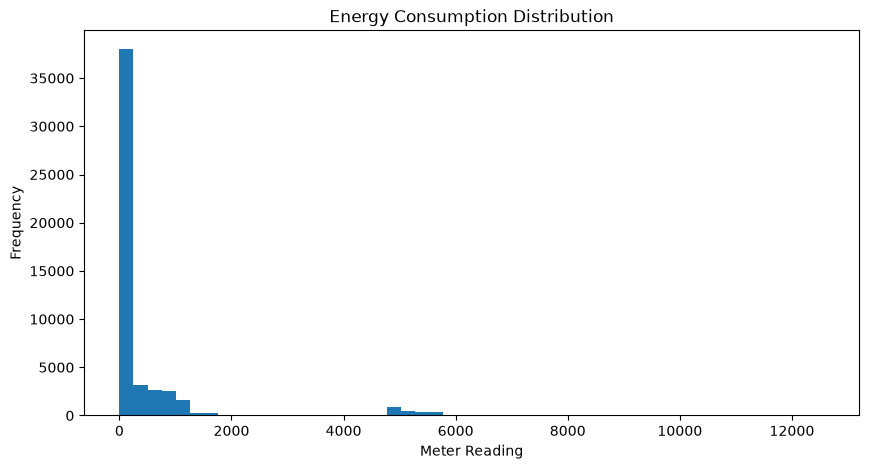

In [6]:
plt.figure(
    figsize=(10, 5)
)

plt.hist(
    df["meter_reading"],
    bins=50
)

plt.title(
    "Energy Consumption Distribution"
)

plt.xlabel(
    "Meter Reading"
)

plt.ylabel(
    "Frequency"
)

plt.show()

In [7]:
daily_energy = (
    df.groupby(
        df["timestamp"].dt.date
    )["meter_reading"]
    .sum()
)

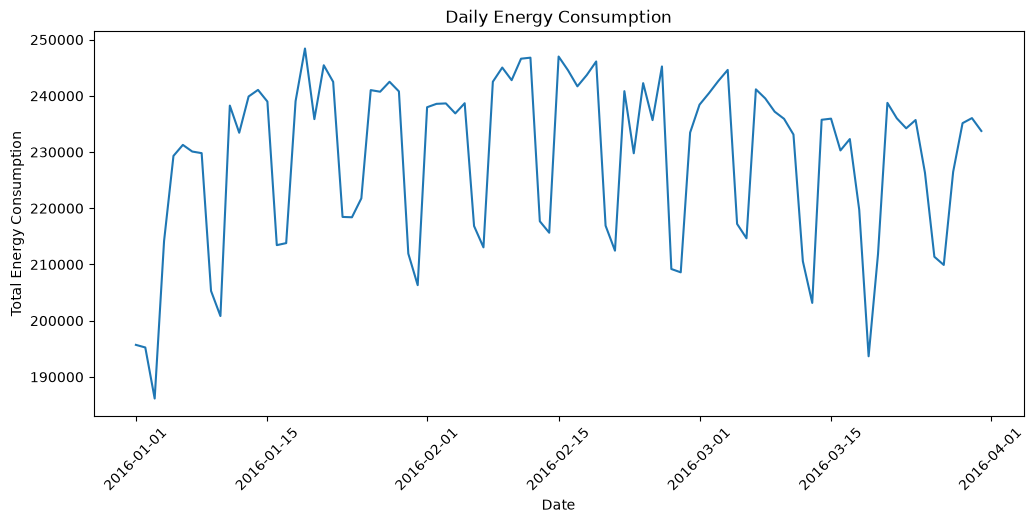

In [8]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    daily_energy.index,
    daily_energy.values
)

plt.title(
    "Daily Energy Consumption"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Total Energy Consumption"
)

plt.xticks(
    rotation=45
)

plt.show()

In [9]:
hourly_energy = (
    df.groupby("hour")[
        "meter_reading"
    ]
    .mean()
)

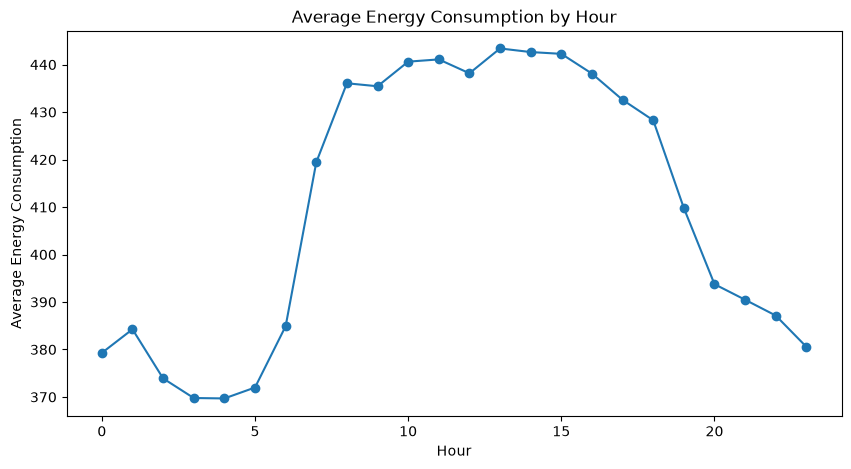

In [10]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    hourly_energy.index,
    hourly_energy.values,
    marker="o"
)

plt.title(
    "Average Energy Consumption by Hour"
)

plt.xlabel(
    "Hour"
)

plt.ylabel(
    "Average Energy Consumption"
)

plt.show()

In [11]:
building_energy = (
    df.groupby(
        "building_id"
    )["meter_reading"]
    .sum()
    .sort_values(
        ascending=False
    )
)

In [12]:
building_energy.head(10)

building_id
803     1.119857e+07
785     2.159754e+06
927     1.900184e+06
560     1.756017e+06
192     1.469368e+06
203     7.757533e+05
123     2.764745e+05
265     2.741818e+05
823     2.572800e+05
1106    2.040610e+05
Name: meter_reading, dtype: float64

In [13]:
top_buildings = (
    building_energy
    .head(10)
)

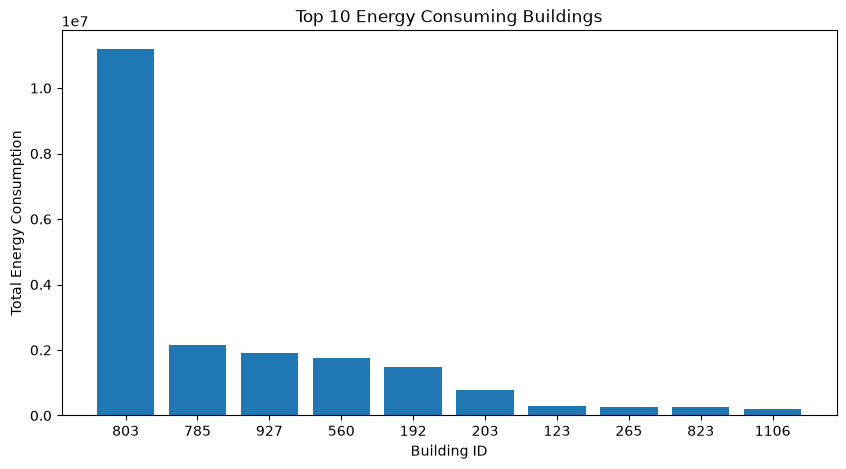

In [14]:
plt.figure(
    figsize=(10, 5)
)

plt.bar(
    top_buildings.index.astype(str),
    top_buildings.values
)

plt.title(
    "Top 10 Energy Consuming Buildings"
)

plt.xlabel(
    "Building ID"
)

plt.ylabel(
    "Total Energy Consumption"
)

plt.show()

In [15]:
weather_energy = (
    df[
        [
            "meter_reading",
            "air_temperature"
        ]
    ]
    .dropna()
)

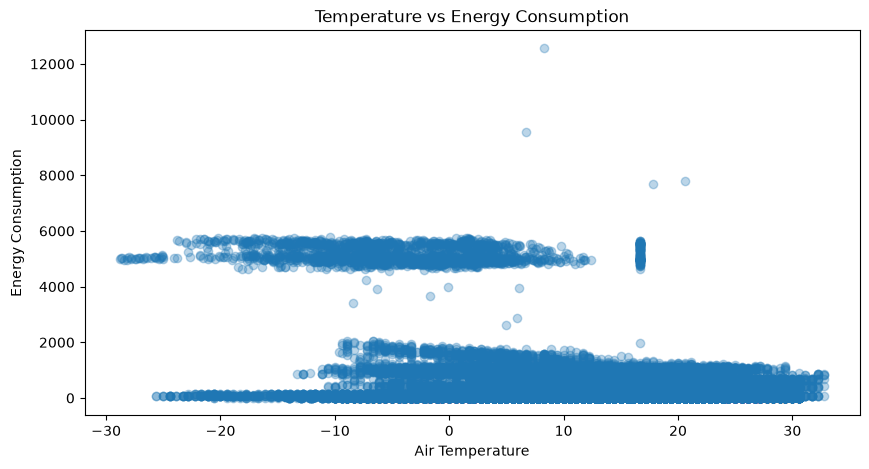

In [16]:
plt.figure(
    figsize=(10, 5)
)

plt.scatter(
    weather_energy["air_temperature"],
    weather_energy["meter_reading"],
    alpha=0.3
)

plt.title(
    "Temperature vs Energy Consumption"
)

plt.xlabel(
    "Air Temperature"
)

plt.ylabel(
    "Energy Consumption"
)

plt.show()

In [17]:
numeric_columns = [
    "meter_reading",
    "air_temperature",
    "dew_temperature",
    "wind_speed",
    "hour",
    "day_of_week",
    "month"
]

correlation = (
    df[numeric_columns]
    .corr()
)

correlation

,meter_reading,air_temperature,dew_temperature,wind_speed,hour,day_of_week,month
meter_reading,1.000000,-0.277924,-0.249606,-0.050138,0.008313,-0.015630,0.009537
air_temperature,-0.277924,1.000000,0.713363,0.005698,0.121945,-0.006637,0.338764
dew_temperature,-0.249606,0.713363,1.000000,-0.001220,-0.012789,0.013467,0.214269
wind_speed,-0.050138,0.005698,-0.001220,1.000000,0.152573,-0.035731,0.028944
hour,0.008313,0.121945,-0.012789,0.152573,1.000000,0.000822,0.000130
day_of_week,-0.015630,-0.006637,0.013467,-0.035731,0.000822,1.000000,-0.058293
month,0.009537,0.338764,0.214269,0.028944,0.000130,-0.058293,1.000000


In [18]:
mean = df[
    "meter_reading"
].mean()

std = df[
    "meter_reading"
].std()


df["z_score"] = (
    df["meter_reading"] - mean
) / std

In [19]:
potential_anomalies = df[
    np.abs(
        df["z_score"]
    ) > 3
]

print(
    "Potential anomalies:",
    len(potential_anomalies)
)

Potential anomalies: 2179
